<a href="https://colab.research.google.com/github/GabrielDaviBrito/AnaliseMultivariada-2026.2/blob/main/AnaliseMultivariadaCOLAB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
from google.colab import userdata

token = userdata.get("GITHUB_TOKEN")

!git clone https://{token}@github.com/GabrielDaviBrito/AnaliseMultivariada-2026.2

fatal: destination path 'AnaliseMultivariada-2026.2' already exists and is not an empty directory.


In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import warnings
df = pd.read_csv('/content/AnaliseMultivariada-2026.2/DADOS_INEP_ANALISE_MULTIVARIADA.csv', sep=",")
df.head()

,Código da Instituição,Nome da Instituição,Categoria Administrativa,Organização Acadêmica,Código do Curso de Graduação,Nome do Curso de Graduação,Código da Região Geográfica do Curso,Código da Unidade Federativa do Curso,Código do Município do Curso,Grau Acadêmico,...,Quantidade de Ingressantes no Curso,Quantidade de Permanência no Curso no ano de referência,Quantidade de Concluintes no Curso no ano de referência,Quantidade de Desistência no Curso no ano de referência,Quantidade de Falecimentos no Curso no ano de referência,Taxa de Permanência - TAP,Taxa de Conclusão Acumulada - TCA,Taxa de Desistência Acumulada - TDA,Taxa de Conclusão Anual - TCAN,Taxa de Desistência Anual - TADA
0,1,UNIVERSIDADE FEDERAL DE MATO GROSSO,1,1,117004,PSICOLOGIA,5,51,5103403,1,...,89,52,26,1,0,"58,4","30,3","11,2","29,2","1,1"
1,2,UNIVERSIDADE DE BRASÍLIA,1,1,22844,PSICOLOGIA,5,53,5300108,1,...,32,0,0,0,0,"0,0","59,4","40,6","0,0","0,0"
2,2,UNIVERSIDADE DE BRASÍLIA,1,1,26033,PSICOLOGIA - PSICÓLOGO,5,53,5300108,1,...,123,62,21,1,0,"50,4","22,8","26,8","17,1","0,8"
3,2,UNIVERSIDADE DE BRASÍLIA,1,1,44376,PSICOLOGIA,5,53,5300108,2,...,30,0,1,0,0,"0,0","46,7","53,3","3,3","0,0"
4,3,UNIVERSIDADE FEDERAL DE SERGIPE,1,1,52852,PSICOLOGIA,2,28,2806701,1,...,46,13,18,1,0,"28,3","39,1","32,6","39,1","2,2"


In [38]:
df.columns

Index(['Código da Instituição', 'Nome da Instituição',
       'Categoria Administrativa', 'Organização Acadêmica',
       'Código do Curso de Graduação', 'Nome do Curso de Graduação',
       'Código da Região Geográfica do Curso',
       'Código da Unidade Federativa do Curso', 'Código do Município do Curso',
       'Grau Acadêmico', 'Modalidade de Ensino',
       'Código da área do Curso segundo a classificação CINE BRASIL',
       'Nome da área do Curso segundo a classificação CINE BRASIL',
       'Código da Grande Área do Curso segundo a classificação CINE BRASIL',
       'Nome da Grande Área do Curso segundo a classificação CINE BRASIL',
       'Ano de Ingresso', 'Ano de Referência',
       'Prazo de Integralização em Anos', 'Ano de Integralização do Curso',
       'Prazo de Acompanhamento do Curso em anos',
       'Ano Máximo de Acompanhamento do Curso',
       'Quantidade de Ingressantes no Curso',
       'Quantidade de Permanência no Curso no ano de referência',
       'Quantida

In [39]:
#Definindo as colunas de interesse
colunas=['Código da Instituição', 'Nome da Instituição','Taxa de Permanência - TAP', 'Taxa de Conclusão Acumulada - TCA',
       'Taxa de Desistência Acumulada - TDA', 'Taxa de Conclusão Anual - TCAN',
       'Taxa de Desistência Anual - TADA']
#Filtrando/renomeando as colunas interessadas
df_filtrado=df[colunas].copy()
df_filtrado=df_filtrado.rename(
    columns={
        'Código da Instituição':'CO_IES',
        'Nome da Instituição':'NO_IES',
        'Taxa de Permanência - TAP':'TAP',
        'Taxa de Conclusão Acumulada - TCA':'TCA',
        'Taxa de Desistência Acumulada - TDA':'TDA',
        'Taxa de Conclusão Anual - TCAN':'TCAN',
        'Taxa de Desistência Anual - TADA':'TADA'
    }
)

#filtrando colunas de taxa para float
taxas=['TAP','TCA','TDA','TCAN','TADA']
for taxa in taxas:
  df_filtrado[taxa]=df_filtrado[taxa].str.replace(',','.').astype(float)
df_filtrado.head()

,CO_IES,NO_IES,TAP,TCA,TDA,TCAN,TADA
0,1,UNIVERSIDADE FEDERAL DE MATO GROSSO,58.4,30.3,11.2,29.2,1.1
1,2,UNIVERSIDADE DE BRASÍLIA,0.0,59.4,40.6,0.0,0.0
2,2,UNIVERSIDADE DE BRASÍLIA,50.4,22.8,26.8,17.1,0.8
3,2,UNIVERSIDADE DE BRASÍLIA,0.0,46.7,53.3,3.3,0.0
4,3,UNIVERSIDADE FEDERAL DE SERGIPE,28.3,39.1,32.6,39.1,2.2


/usr/local/lib/python3.13/dist-packages/seaborn/axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
/usr/local/lib/python3.13/dist-packages/seaborn/axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
/usr/local/lib/python3.13/dist-packages/seaborn/axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
/usr/local/lib/python3.13/dist-packages/seaborn/axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
/usr/local/lib/python3.13/dist-packages/seaborn/axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
/usr/local/lib/python3.13/dist-packages/seaborn/axisgrid.py:1615: UserWarning: Ignoring `palette` because no `hue` variable h

<Figure size 1000x600 with 0 Axes>

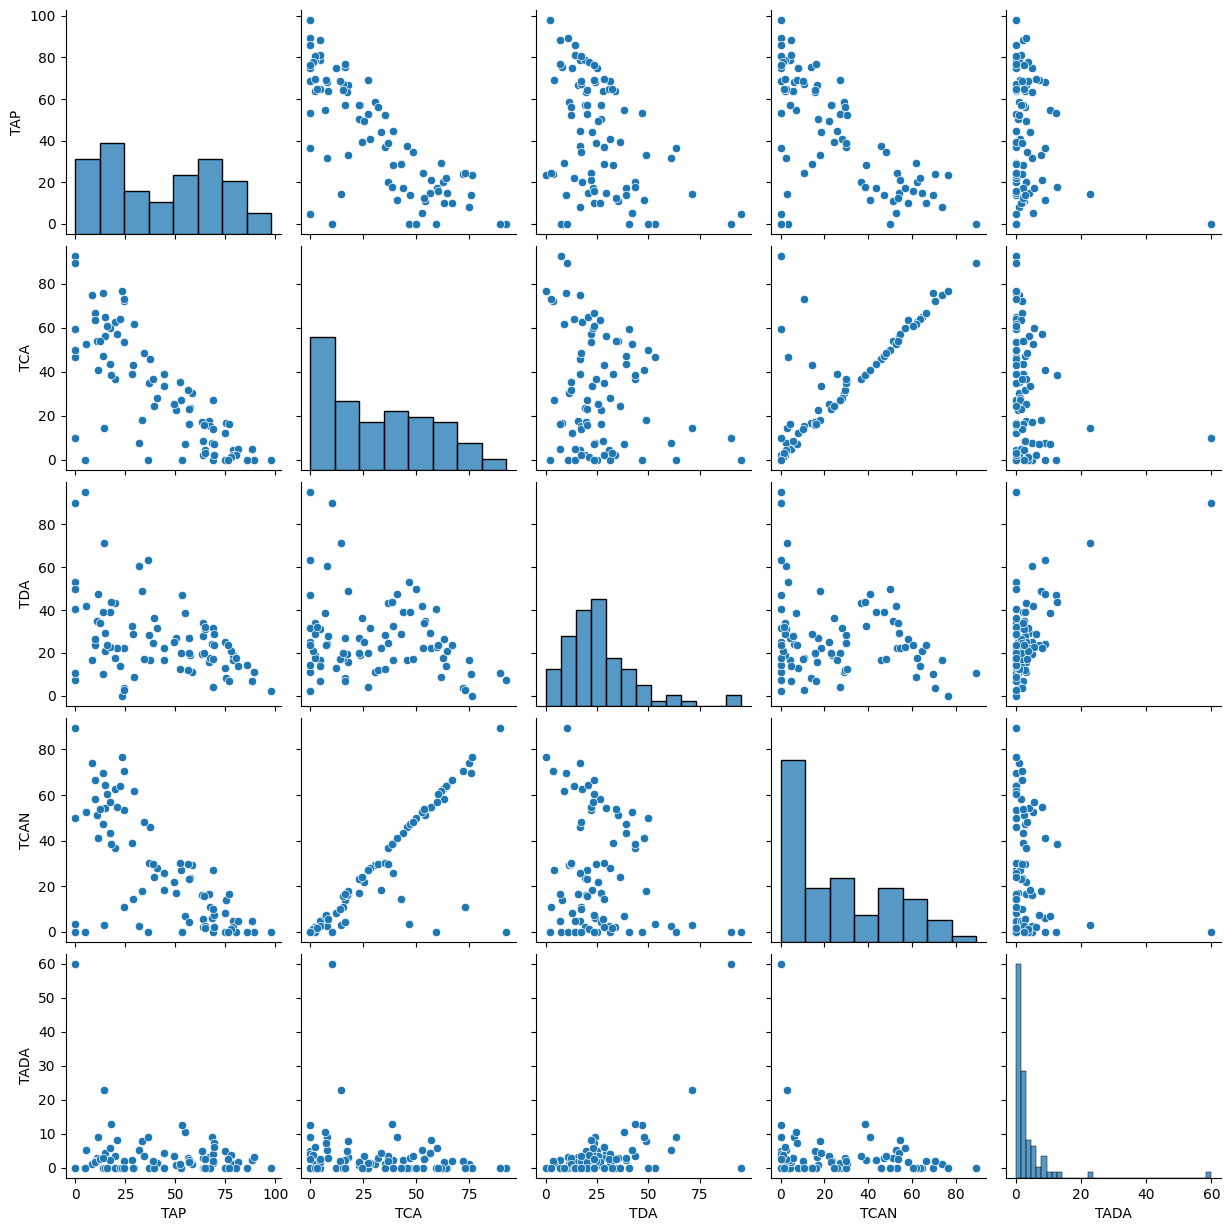

In [40]:
plt.figure(figsize=(10, 6))
grafico_pairwise = sns.pairplot(df_filtrado[taxas], kind="scatter", markers=["o", "s",
"D"], palette="Set2")
plt.show()

In [22]:
print(df_filtrado[taxas].columns)

Index(['TAP', 'TCA', 'TDA', 'TCAN', 'TADA'], dtype='object')


In [41]:
print(df_filtrado[taxas].columns)
dados_pca = df_filtrado[taxas].iloc[:,range(5)]

#Correlação de Pearson
corr_pearson = dados_pca.corr(method="pearson")
print(corr_pearson)

Index(['TAP', 'TCA', 'TDA', 'TCAN', 'TADA'], dtype='object')
           TAP       TCA       TDA      TCAN      TADA
TAP   1.000000 -0.777516 -0.427510 -0.623118 -0.178439
TCA  -0.777516  1.000000 -0.236102  0.830947 -0.202237
TDA  -0.427510 -0.236102  1.000000 -0.231753  0.566554
TCAN -0.623118  0.830947 -0.231753  1.000000 -0.187577
TADA -0.178439 -0.202237  0.566554 -0.187577  1.000000


In [47]:
pca = PCA(n_components=5)
pca.fit(dados_pca)
resultados_acp= pca.fit_transform(dados_pca)
print(pca.components_)

prop_var = pca.explained_variance_ratio_

prop_pc = pd.DataFrame({
    'Componentes': ['CP1', 'CP2', 'CP3', 'CP4', 'CP5'],
    'Prop. Var Explicada pelo CP ': prop_var,
    'Prop. Var Explicada pelo CP  Acum': np.cumsum(prop_var)
})

print(prop_pc)

[[ 6.01453010e-01 -5.96320278e-01 -5.06082692e-03 -5.31505351e-01
   1.15261800e-02]
 [-5.11772939e-01 -2.26624910e-01  7.38431735e-01 -3.27899392e-01
   1.84201441e-01]
 [ 1.96276611e-01 -4.98289220e-01  3.01814064e-01  7.80718364e-01
   1.12118025e-01]
 [ 6.70397332e-02  1.07140324e-01 -1.73773639e-01 -2.15144435e-02
   9.76404873e-01]
 [ 5.77342102e-01  5.77297220e-01  5.77411424e-01  1.23021876e-04
  -2.20339413e-04]]
  Componentes  Prop. Var Explicada pelo CP   Prop. Var Explicada pelo CP  Acum
0         CP1                  7.002979e-01                           0.700298
1         CP2                  2.337314e-01                           0.934029
2         CP3                  5.136214e-02                           0.985391
3         CP4                  1.460840e-02                           1.000000
4         CP5                  2.015901e-07                           1.000000
